# Section B — Practical Task
## Assess the model's performance by calculating the **Mean Absolute Error (MAE)** of its predictions.

**Trade:** Artificial Intelligence (Machine Learning, Deep Learning, Communication)  
**NAVTTC Practical Paper**

---
## What is Mean Absolute Error (MAE)?

MAE measures the **average magnitude of errors** between predicted and actual values — without considering direction.

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- $y_i$ = actual value  
- $\hat{y}_i$ = predicted value  
- $n$ = number of samples  
- **Lower MAE = Better model performance**

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Create a Sample Dataset (House Prices)

In [3]:
# Sample dataset: House size (sq ft) vs Price (PKR in thousands)
np.random.seed(42)

house_size  = np.array([500, 750, 800, 1000, 1200, 1500,
                        1800, 2000, 2200, 2500, 2800, 3000])
house_price = np.array([1500, 2000, 2100, 2500, 2900, 3400,
                        3900, 4200, 4500, 5000, 5400, 5800])

df = pd.DataFrame({'House Size (sq ft)': house_size,
                   'Price (PKR 000s)': house_price})

print('Dataset:')
print(df.to_string(index=False))

Dataset:
 House Size (sq ft)  Price (PKR 000s)
                500              1500
                750              2000
                800              2100
               1000              2500
               1200              2900
               1500              3400
               1800              3900
               2000              4200
               2200              4500
               2500              5000
               2800              5400
               3000              5800


## 3. Split into Training and Testing Sets

In [4]:
X = house_size.reshape(-1, 1)   # Feature  (2D array required by sklearn)
y = house_price                  # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 9
Testing  samples : 3


## 4. Train a Linear Regression Model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Model trained successfully!')
print(f'Coefficient (slope)  : {model.coef_[0]:.4f}')
print(f'Intercept            : {model.intercept_:.4f}')
print(f'Equation             : Price = {model.coef_[0]:.2f} × Size + ({model.intercept_:.2f})')

Model trained successfully!
Coefficient (slope)  : 1.6829
Intercept            : 813.1582
Equation             : Price = 1.68 × Size + (813.16)


## 5. Make Predictions

In [6]:
y_pred = model.predict(X_test)

# Show actual vs predicted
results = pd.DataFrame({
    'House Size': X_test.flatten(),
    'Actual Price': y_test,
    'Predicted Price': np.round(y_pred, 2),
    'Absolute Error': np.abs(y_test - y_pred).round(2)
})

print('Prediction Results:')
print(results.to_string(index=False))

Prediction Results:
 House Size  Actual Price  Predicted Price  Absolute Error
       2800          5400          5525.33          125.33
       2500          5000          5020.45           20.45
        500          1500          1654.62          154.62


## 6. Calculate MAE — Method 1: Manual (From Scratch)

In [7]:
# Step-by-step manual calculation
n = len(y_test)
absolute_errors = [abs(actual - predicted) for actual, predicted in zip(y_test, y_pred)]
mae_manual = sum(absolute_errors) / n

print('Manual MAE Calculation:')
print(f'  Absolute errors  : {[round(e,2) for e in absolute_errors]}')
print(f'  Sum of errors    : {sum(absolute_errors):.4f}')
print(f'  Number of samples: {n}')
print(f'  MAE (manual)     : {sum(absolute_errors):.4f} / {n} = {mae_manual:.4f}')

Manual MAE Calculation:
  Absolute errors  : [np.float64(125.33), np.float64(20.45), np.float64(154.62)]
  Sum of errors    : 300.3968
  Number of samples: 3
  MAE (manual)     : 300.3968 / 3 = 100.1323


## 7. Calculate MAE — Method 2: Using NumPy

In [8]:
mae_numpy = np.mean(np.abs(y_test - y_pred))
print(f'MAE (NumPy)      : {mae_numpy:.4f}')

MAE (NumPy)      : 100.1323


## 8. Calculate MAE — Method 3: Using Scikit-learn

In [9]:
mae_sklearn = mean_absolute_error(y_test, y_pred)
print(f'MAE (Scikit-learn): {mae_sklearn:.4f}')
print()
print('=' * 45)
print(f'  FINAL MAE = {mae_sklearn:.4f} PKR (thousands)')
print('=' * 45)
print()
print('Interpretation:')
print(f'  On average, the model\'s predictions are off by')
print(f'  PKR {mae_sklearn:.0f},000 from the actual house prices.')

MAE (Scikit-learn): 100.1323

  FINAL MAE = 100.1323 PKR (thousands)

Interpretation:
  On average, the model's predictions are off by
  PKR 100,000 from the actual house prices.


## 9. Visualize — Actual vs Predicted

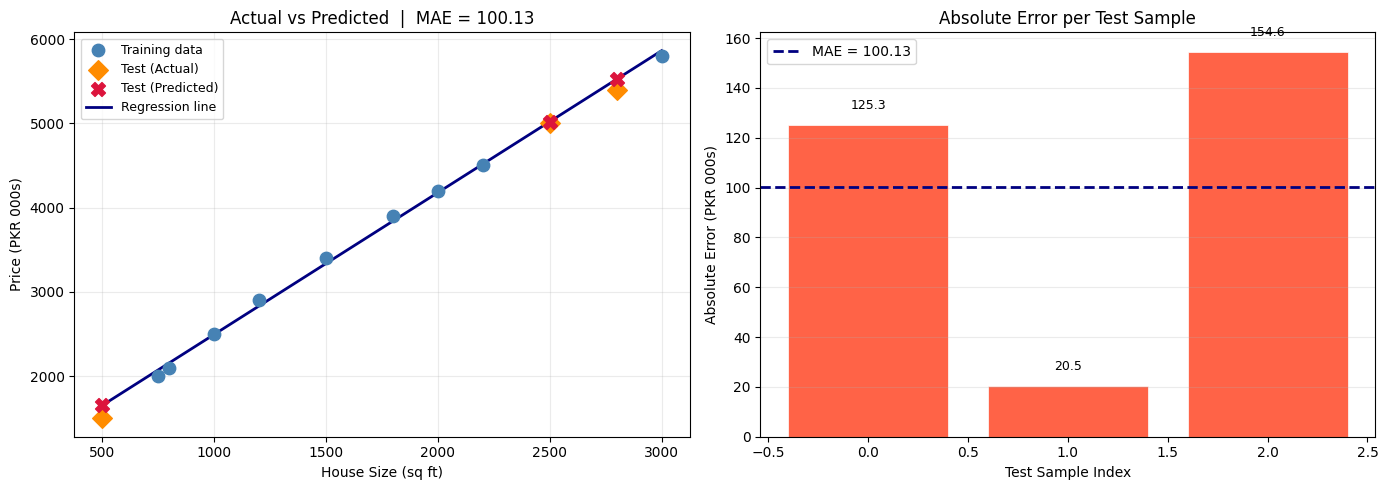

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Regression line ───────────────────────────────
ax = axes[0]
ax.scatter(X_train, y_train, color='steelblue', s=80,
           label='Training data', zorder=3)
ax.scatter(X_test, y_test, color='darkorange', s=100,
           marker='D', label='Test (Actual)', zorder=4)
ax.scatter(X_test, y_pred, color='crimson', s=100,
           marker='X', label='Test (Predicted)', zorder=5)

# Draw error lines
for xi, ya, yp in zip(X_test, y_test, y_pred):
    ax.plot([xi, xi], [ya, yp], color='gray',
            linestyle='--', linewidth=1, alpha=0.7)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
ax.plot(x_line, model.predict(x_line), color='navy',
        linewidth=2, label='Regression line')

ax.set_xlabel('House Size (sq ft)')
ax.set_ylabel('Price (PKR 000s)')
ax.set_title(f'Actual vs Predicted  |  MAE = {mae_sklearn:.2f}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# ── Plot 2: Absolute Error per sample ────────────────────
ax2 = axes[1]
bars = ax2.bar(range(len(y_test)), np.abs(y_test - y_pred),
               color='tomato', edgecolor='white', linewidth=0.5)
ax2.axhline(y=mae_sklearn, color='navy', linestyle='--',
            linewidth=2, label=f'MAE = {mae_sklearn:.2f}')

for bar, err in zip(bars, np.abs(y_test - y_pred)):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5, f'{err:.1f}',
             ha='center', va='bottom', fontsize=9)

ax2.set_xlabel('Test Sample Index')
ax2.set_ylabel('Absolute Error (PKR 000s)')
ax2.set_title('Absolute Error per Test Sample')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('mae_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary of All Metrics

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 50)
print('       MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Mean Absolute Error  (MAE)  : {mae_sklearn:.4f}')
print(f'  Mean Squared Error   (MSE)  : {mse:.4f}')
print(f'  Root Mean Sq. Error  (RMSE) : {rmse:.4f}')
print(f'  R² Score                    : {r2:.4f}')
print('=' * 50)
print()
print('Conclusion:')
if mae_sklearn < 200:
    print('  ✅ MAE is LOW  — Model performs WELL.')
else:
    print('  ⚠️  MAE is HIGH — Model needs improvement.')
print(f'  R² = {r2:.2f} means the model explains {r2*100:.1f}%')
print('  of the variance in house prices.')

       MODEL PERFORMANCE SUMMARY
  Mean Absolute Error  (MAE)  : 100.1323
  Mean Squared Error   (MSE)  : 13343.9044
  Root Mean Sq. Error  (RMSE) : 115.5158
  R² Score                    : 0.9957

Conclusion:
  ✅ MAE is LOW  — Model performs WELL.
  R² = 1.00 means the model explains 99.6%
  of the variance in house prices.


---
## Concept Summary

| Method | Code | Result |
|--------|------|--------|
| **Manual** | `sum(|actual - predicted|) / n` | Same |
| **NumPy** | `np.mean(np.abs(y_test - y_pred))` | Same |
| **Scikit-learn** | `mean_absolute_error(y_test, y_pred)` | Same |

> **Key takeaway:** MAE tells you, in the same units as your target variable, how far off your model's predictions are on average. Lower MAE = better model.